<a href="https://colab.research.google.com/github/saurav81kumar/machine-learning/blob/main/House_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

In [3]:
house_price_dataset = pd.read_csv('/content/Housing.csv', header=None)

In [4]:
house_price_dataset.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
1,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
2,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
3,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
4,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished


In [12]:
column_names = house_price_dataset.iloc[0]
house_price_dataframe = pd.DataFrame(house_price_dataset.iloc[1:].values, columns=column_names)

In [7]:
house_price_dataframe.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [13]:
house_price_dataframe['price'] = pd.to_numeric(house_price_dataframe['price'])

In [14]:
house_price_dataframe.shape

(545, 13)

In [15]:
house_price_dataframe.isnull().sum()

,0
0,
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0


In [16]:
house_price_dataframe.describe()

,price
count,5.450000e+02
mean,4.766729e+06
std,1.870440e+06
min,1.750000e+06
25%,3.430000e+06
50%,4.340000e+06
75%,5.740000e+06
max,1.330000e+07


In [18]:
# Convert 'area', 'bedrooms', 'bathrooms', 'stories', 'parking' to numeric if they aren't already
numeric_cols = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
for col in numeric_cols:
    house_price_dataframe[col] = pd.to_numeric(house_price_dataframe[col])

# Convert binary categorical columns ('yes'/'no') to 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    house_price_dataframe[col] = house_price_dataframe[col].map({'yes': 1, 'no': 0})

# Convert 'furnishingstatus' using one-hot encoding
house_price_dataframe = pd.get_dummies(house_price_dataframe, columns=['furnishingstatus'], drop_first=True)

correlation = house_price_dataframe.corr()

<Axes: >

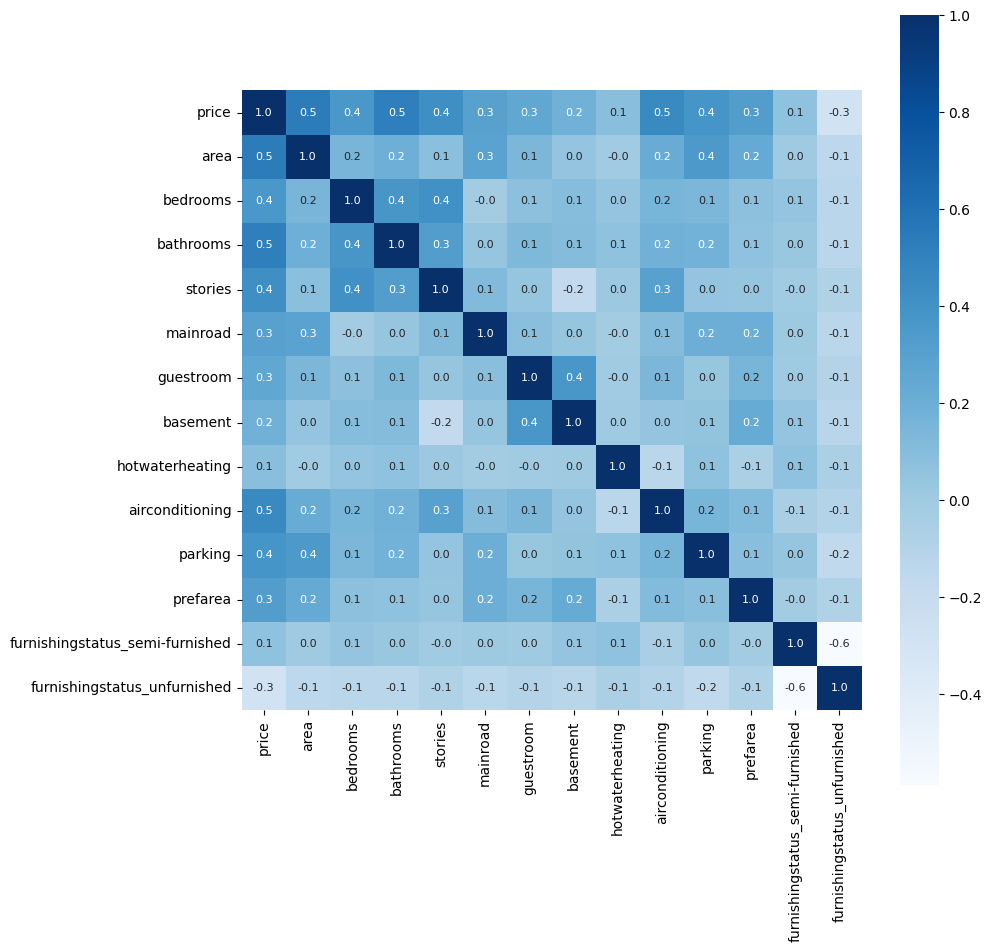

In [19]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

In [20]:
X = house_price_dataframe.drop(['price'], axis=1)
Y = house_price_dataframe['price']

In [21]:
print(X)
print(Y)

     area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0    7420         4          2        3         1          0         0   
1    8960         4          4        4         1          0         0   
2    9960         3          2        2         1          0         1   
3    7500         4          2        2         1          0         1   
4    7420         4          1        2         1          1         1   
..    ...       ...        ...      ...       ...        ...       ...   
540  3000         2          1        1         1          0         1   
541  2400         3          1        1         0          0         0   
542  3620         2          1        1         1          0         0   
543  2910         3          1        1         0          0         0   
544  3850         3          1        2         1          0         0   

     hotwaterheating  airconditioning  parking  prefarea  \
0                  0                1        2     

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)

In [23]:
print(X.shape, X_train.shape, X_test.shape)

(545, 13) (436, 13) (109, 13)


In [24]:
model = XGBRegressor()

In [25]:
model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [26]:
training_data_prediction = model.predict(X_train)

In [27]:
print(training_data_prediction)

[ 3438188.8  4281129.   2667358.5  4812158.5  4268975.5  6982451.
  2899728.5  2683421.2  6925460.5  4714649.5  3334021.5  2903115.2
  6013163.   5795081.   7749618.   4125183.5  5168867.5  4565617.5
  7773872.5  4214846.5  4154218.   2624302.2  5250467.   4393154.
  3908956.2  4018865.2  6803246.5  9187685.   4574320.   3224010.2
  3781915.2  3053271.2  2284534.   4064189.   4163488.5  2945800.5
  4816967.   3640095.8  1917441.2  7991870.5  4135193.5 12211004.
  8530454.   7395427.   4041375.8  3204269.   4307224.   3609342.2
  3347100.8  2448670.   5895991.   4106645.   3832236.5  3273263.2
  4109959.5  5367613.5  3654255.2  3805759.2  3687478.   4193219.5
  7492358.5  4316850.5  5981586.5  2877616.2  3822975.8  5519497.5
  6629760.5  5829262.   5486160.   5635250.   3254425.2  3638413.5
  2827257.2  4862930.5  5250813.5  3737208.   5883398.5  4222694.5
  6747761.5  5395359.   3094985.5  3613329.   6649819.5  4891540.
  5898450.5  8417626.   2656258.5  3312247.   9776475.   4102822.8

In [28]:
score_1 = metrics.r2_score(Y_train, training_data_prediction)

# Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_train, training_data_prediction)

print("R squared error : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared error :  0.9974787831306458
Mean Absolute Error :  50480.21484375


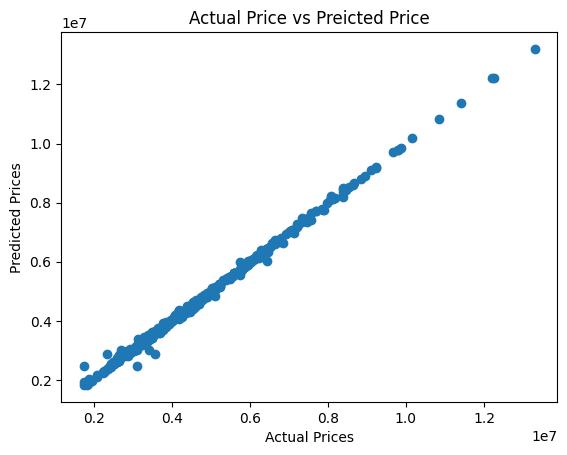

In [29]:
plt.scatter(Y_train, training_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Price vs Preicted Price")
plt.show()

In [30]:
test_data_prediction = model.predict(X_test)

In [31]:
score_1 = metrics.r2_score(Y_test, test_data_prediction)

# Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_test, test_data_prediction)

print("R squared error : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared error :  0.4640995264053345
Mean Absolute Error :  925924.75
